# Regime Switching and MS-GARCH Parameter Analysis

This notebook analyzes regime switching and MS-GARCH parameters to understand:
- How often we are in each regime
- Parameter differences between regimes
- Transition dynamics and regime persistence
- Volatility patterns across regimes

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load and Explore Data

In [2]:
# Load the data
rs_params = pd.read_csv('data/output/regime_switching_parameters.csv')
ms_garch = pd.read_csv('data/output/ms_garch_parameters.csv')

# Convert date columns to datetime
rs_params['date'] = pd.to_datetime(rs_params['date'])
ms_garch['date'] = pd.to_datetime(ms_garch['date'])

print('Regime Switching Parameters:')
print(f'Shape: {rs_params.shape}')
print(f'Date range: {rs_params["date"].min()} to {rs_params["date"].max()}')
print(f'Number of companies: {rs_params["gvkey"].nunique()}')
print()
print('MS-GARCH Parameters:')
print(f'Shape: {ms_garch.shape}')
print(f'Date range: {ms_garch["date"].min()} to {ms_garch["date"].max()}')
print(f'Number of companies: {ms_garch["gvkey"].nunique()}')

Regime Switching Parameters:
Shape: (5233, 14)
Date range: 2011-12-30 00:00:00 to 2024-12-31 00:00:00
Number of companies: 34

MS-GARCH Parameters:
Shape: (5233, 18)
Date range: 2011-12-30 00:00:00 to 2024-12-31 00:00:00
Number of companies: 34


In [3]:
# Display first few rows of each dataset
print('Regime Switching Parameters - First 5 rows:')
display(rs_params.head())

print('\nMS-GARCH Parameters - First 5 rows:')
display(ms_garch.head())

Regime Switching Parameters - First 5 rows:


,gvkey,date,regime_0_mean,regime_1_mean,regime_0_vol,regime_1_vol,regime_0_nu,regime_1_nu,transition_prob_00,transition_prob_01,transition_prob_10,transition_prob_11,regime_0_ar,regime_1_ar
0,14447,2012-02-29,0.001141,-0.001652,0.012694,0.022005,6.583043,405.428793,0.990847,0.009153,0.031831,0.968169,0.0,0.0
1,14447,2012-03-30,0.001119,-0.001662,0.012858,0.022052,6.670415,405.428793,0.991405,0.008595,0.026899,0.973101,0.0,0.0
2,14447,2012-04-30,0.000888,-0.001819,0.013072,0.022156,8.710389,405.428793,0.991562,0.008438,0.027140,0.972860,0.0,0.0
3,14447,2012-05-31,0.000993,-0.002110,0.013578,0.022348,11.350404,405.428793,0.991652,0.008348,0.029172,0.970828,0.0,0.0
4,14447,2012-06-29,0.000580,-0.001906,0.013736,0.022199,8.766476,405.428793,0.991093,0.008907,0.028993,0.971007,0.0,0.0



MS-GARCH Parameters - First 5 rows:


,gvkey,date,omega_0,alpha_0,beta_0,omega_1,alpha_1,beta_1,mu_0,mu_1,p00,p11,nu_0,nu_1,log_likelihood,aic,bic,n_obs
0,14447,2012-02-29,0.000460,0.000035,0.045003,0.000059,2.886834e-07,0.635308,-0.001616,0.001122,0.972840,0.992092,8734.632059,6.569169,-1614.357494,3252.714987,3295.068136,252
1,14447,2012-03-30,0.000457,0.000015,0.061489,0.000111,4.445956e-07,0.334033,-0.001696,0.001107,0.973951,0.993531,4116.429868,6.649532,-1615.788402,3255.576805,3297.929954,252
2,14447,2012-04-30,0.000449,0.000009,0.090112,0.000059,7.437570e-08,0.658486,-0.001863,0.000874,0.973386,0.993759,2205.697753,8.692730,-1620.126862,3264.253724,3306.606873,252
3,14447,2012-05-31,0.000441,0.000038,0.119521,0.000097,1.712623e-06,0.477426,-0.002145,0.000983,0.972055,0.993670,6854.598737,11.358034,-1627.402409,3278.804819,3321.157968,252
4,14447,2012-06-29,0.000433,0.000687,0.125692,0.000093,3.516497e-04,0.511490,-0.001954,0.000569,0.972666,0.993355,15792.108676,8.765119,-1629.025712,3282.051423,3324.404573,252


In [4]:
# Summary statistics
print('Regime Switching - Summary Statistics:')
display(rs_params.describe())

print('\nMS-GARCH - Summary Statistics:')
display(ms_garch.describe())

Regime Switching - Summary Statistics:


,gvkey,date,regime_0_mean,regime_1_mean,regime_0_vol,regime_1_vol,regime_0_nu,regime_1_nu,transition_prob_00,transition_prob_01,transition_prob_10,transition_prob_11,regime_0_ar,regime_1_ar
count,5233.000000,5233,5233.000000,5233.000000,5233.000000,5233.000000,5233.000000,5233.000000,5233.000000,5233.000000,5233.000000,5233.000000,5233.0,5233.0
mean,96976.148099,2018-08-16 07:12:34.672272,-0.000912,0.000439,0.004692,0.018012,128.073291,47.619798,0.721770,0.278230,0.292503,0.707497,0.0,0.0
min,14447.000000,2011-12-30 00:00:00,-0.156684,-0.121781,0.000006,0.000424,2.001000,2.001000,0.010000,0.001000,0.001000,0.010000,0.0,0.0
25%,17452.000000,2015-05-29 00:00:00,-0.000198,-0.000307,0.000816,0.007532,3.446629,2.001000,0.500000,0.028642,0.012656,0.399012,0.0,0.0
50%,100581.000000,2018-08-31 00:00:00,0.000198,0.000024,0.004177,0.013375,6.881924,3.008979,0.915819,0.084181,0.091667,0.908333,0.0,0.0
75%,132740.000000,2021-10-29 00:00:00,0.001027,0.000434,0.007419,0.026064,404.760940,6.116043,0.971358,0.500000,0.600988,0.987344,0.0,0.0
max,241637.000000,2024-12-31 00:00:00,0.198359,0.104155,0.044817,0.044817,405.428793,405.428793,0.999000,0.990000,0.990000,0.999000,0.0,0.0
std,79535.790486,NaN,0.035158,0.012472,0.004336,0.013514,182.152988,123.508524,0.319885,0.319885,0.337456,0.337456,0.0,0.0



MS-GARCH - Summary Statistics:


,gvkey,date,omega_0,alpha_0,beta_0,omega_1,alpha_1,beta_1,mu_0,mu_1,p00,p11,nu_0,nu_1,log_likelihood,aic,bic,n_obs
count,5233.000000,5233,5.233000e+03,5.233000e+03,5.233000e+03,5.233000e+03,5.233000e+03,5.233000e+03,5233.000000,5233.000000,5233.000000,5233.000000,5.233000e+03,5233.000000,5233.000000,5233.000000,5233.000000,5233.0
mean,96976.148099,2018-08-16 07:12:34.672272,6.726288e-06,7.989692e-02,4.196813e-01,6.104755e+04,1.406747e-01,5.950140e-01,0.005166,-0.000457,0.781162,0.900281,1.420542e+08,25.416403,-1348.535394,2721.070788,2763.423937,252.0
min,14447.000000,2011-12-30 00:00:00,8.130990e-94,2.971137e-97,7.534300e-44,1.415306e-14,4.550928e-49,1.508187e-21,-0.118779,-0.073270,0.002543,0.001508,2.000000e+00,2.000000,-2284.453083,1537.329905,1579.683054,252.0
25%,17452.000000,2015-05-29 00:00:00,1.080455e-13,1.000000e-03,1.014707e-03,4.920927e-07,7.755140e-03,1.145036e-01,-0.000229,-0.000377,0.651272,0.862614,3.923538e+00,2.655581,-1508.344358,2553.400058,2595.753207,252.0
50%,100581.000000,2018-08-31 00:00:00,2.211890e-08,4.903461e-03,2.831238e-01,4.709006e-06,6.148002e-02,7.748166e-01,0.000070,0.000104,0.813922,0.975482,1.909680e+01,3.361052,-1417.089556,2858.179112,2900.532261,252.0
75%,132740.000000,2021-10-29 00:00:00,6.612204e-07,6.834480e-02,9.240248e-01,2.749619e-05,1.717844e-01,9.316965e-01,0.005581,0.000374,0.961353,0.990000,9.400087e+01,5.321729,-1264.700029,3040.688717,3083.041866,252.0
max,241637.000000,2024-12-31 00:00:00,4.596875e-04,9.989504e-01,9.988757e-01,3.194566e+08,9.980382e-01,9.986348e-01,0.259461,0.045685,1.000000,1.000000,7.420588e+11,35367.396631,-756.664952,4592.906167,4635.259316,252.0
std,79535.790486,NaN,2.660905e-05,2.000275e-01,4.254680e-01,4.416076e+06,2.169350e-01,3.843226e-01,0.042763,0.002827,0.186218,0.146346,1.025802e+10,595.372748,229.550488,459.100977,459.100977,0.0


## 3. Regime Frequency Analysis

Calculate how often we are in each regime using steady-state probabilities from the transition matrix.

In [29]:
def calculate_steady_state_probabilities(p00, p11):
    """
    Calculate steady-state probabilities for a 2-state Markov chain.
    
    For a transition matrix:
    P = [[p00, p01],
         [p10, p11]]
    
    Steady state: pi = pi * P
    pi_0 = (1 - p11) / (2 - p00 - p11)
    pi_1 = (1 - p00) / (2 - p00 - p11)
    """
    pi_0 = (1 - p11) / (2 - p00 - p11)
    pi_1 = (1 - p00) / (2 - p00 - p11)
    return pi_0, pi_1

# Calculate steady-state probabilities for regime switching
rs_params['steady_state_regime_0'] = rs_params.apply(
    lambda row: calculate_steady_state_probabilities(row['transition_prob_00'], row['transition_prob_11'])[0],
    axis=1
)
rs_params['steady_state_regime_1'] = rs_params.apply(
    lambda row: calculate_steady_state_probabilities(row['transition_prob_00'], row['transition_prob_11'])[1],
    axis=1
)

# Calculate for MS-GARCH
ms_garch['steady_state_regime_0'] = ms_garch.apply(
    lambda row: calculate_steady_state_probabilities(row['p00'], row['p11'])[0],
    axis=1
)
ms_garch['steady_state_regime_1'] = ms_garch.apply(
    lambda row: calculate_steady_state_probabilities(row['p00'], row['p11'])[1],
    axis=1
)

print('Regime Switching - Average Time in Each Regime:')
print(f'Regime 0: {rs_params["steady_state_regime_0"].mean():.2%}')
print(f'Regime 1: {rs_params["steady_state_regime_1"].mean():.2%}')

print('\nMS-GARCH - Average Time in Each Regime:')
print(f'Regime 0: {ms_garch["steady_state_regime_0"].mean():.2%}')
print(f'Regime 1: {ms_garch["steady_state_regime_1"].mean():.2%}')

Regime Switching - Average Time in Each Regime:
Regime 0: 50.87%
Regime 1: 49.13%

MS-GARCH - Average Time in Each Regime:
Regime 0: 34.78%
Regime 1: 65.22%


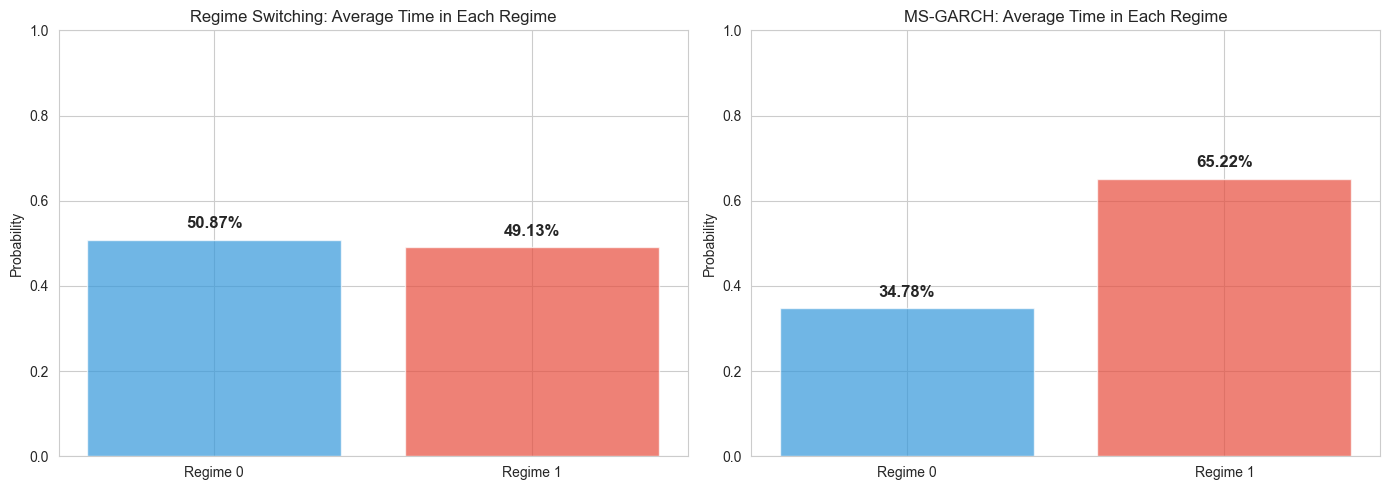

In [30]:
# Visualize regime frequencies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime Switching
rs_regime_freq = rs_params[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[0].bar(['Regime 0', 'Regime 1'], rs_regime_freq, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Probability')
axes[0].set_title('Regime Switching: Average Time in Each Regime')
axes[0].set_ylim([0, 1])
for i, v in enumerate(rs_regime_freq):
    axes[0].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# MS-GARCH
ms_regime_freq = ms_garch[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[1].bar(['Regime 0', 'Regime 1'], ms_regime_freq, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Probability')
axes[1].set_title('MS-GARCH: Average Time in Each Regime')
axes[1].set_ylim([0, 1])
for i, v in enumerate(ms_regime_freq):
    axes[1].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

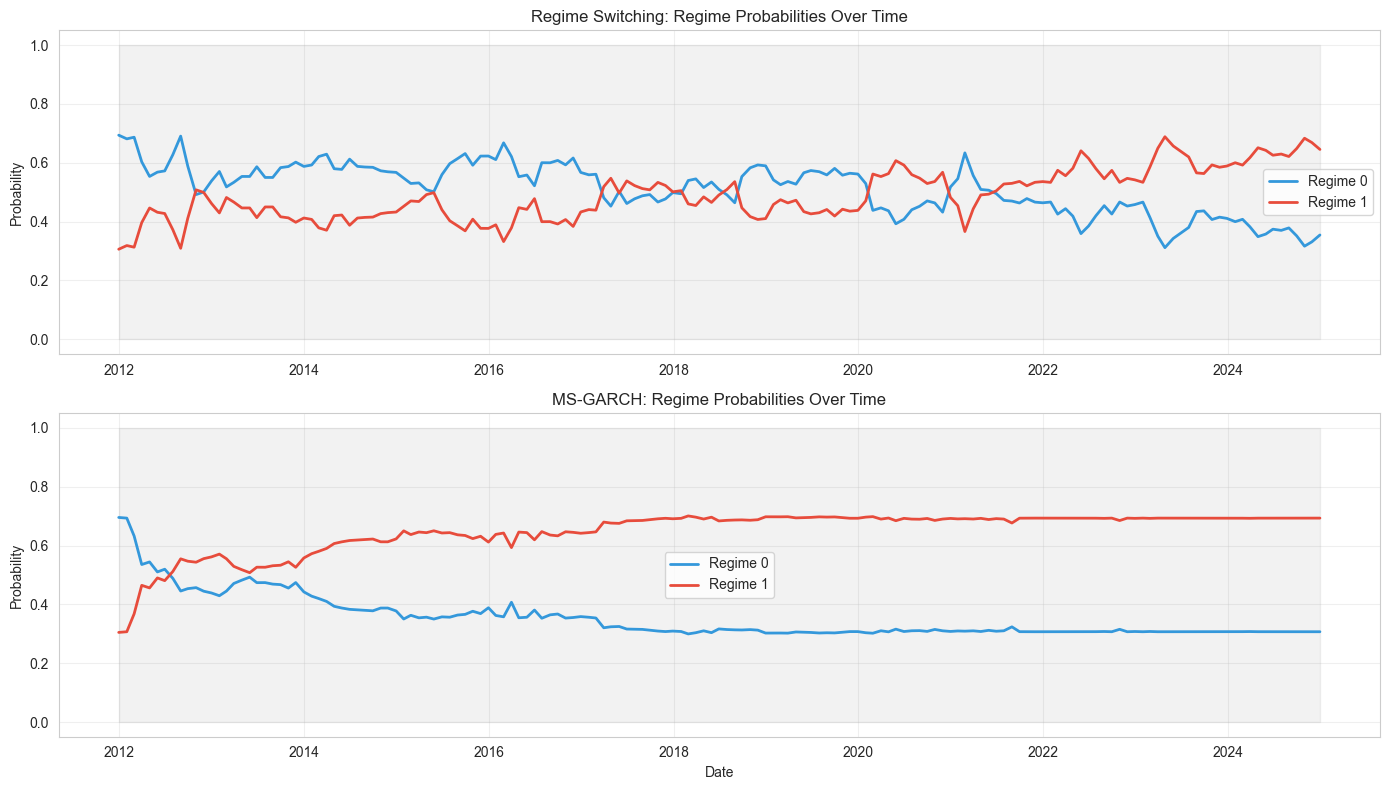

In [31]:
# Distribution of regime frequencies across time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Regime Switching over time
rs_time = rs_params.groupby('date')[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[0].plot(rs_time.index, rs_time['steady_state_regime_0'], label='Regime 0', color='#3498db', linewidth=2)
axes[0].plot(rs_time.index, rs_time['steady_state_regime_1'], label='Regime 1', color='#e74c3c', linewidth=2)
axes[0].fill_between(rs_time.index, 0, 1, alpha=0.1, color='gray')
axes[0].set_ylabel('Probability')
axes[0].set_title('Regime Switching: Regime Probabilities Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MS-GARCH over time
ms_time = ms_garch.groupby('date')[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[1].plot(ms_time.index, ms_time['steady_state_regime_0'], label='Regime 0', color='#3498db', linewidth=2)
axes[1].plot(ms_time.index, ms_time['steady_state_regime_1'], label='Regime 1', color='#e74c3c', linewidth=2)
axes[1].fill_between(ms_time.index, 0, 1, alpha=0.1, color='gray')
axes[1].set_ylabel('Probability')
axes[1].set_xlabel('Date')
axes[1].set_title('MS-GARCH: Regime Probabilities Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Regime Duration Analysis

Expected duration in regime i: 1 / (1 - p_ii)

In [32]:
# Calculate expected durations
rs_params['duration_regime_0'] = 1 / (1 - rs_params['transition_prob_00'])
rs_params['duration_regime_1'] = 1 / (1 - rs_params['transition_prob_11'])

ms_garch['duration_regime_0'] = 1 / (1 - ms_garch['p00'])
ms_garch['duration_regime_1'] = 1 / (1 - ms_garch['p11'])

print('Regime Switching - Expected Duration (in periods):')
print(f'Regime 0: {rs_params["duration_regime_0"].mean():.2f} ± {rs_params["duration_regime_0"].std():.2f}')
print(f'Regime 1: {rs_params["duration_regime_1"].mean():.2f} ± {rs_params["duration_regime_1"].std():.2f}')

print('\nMS-GARCH - Expected Duration (in periods):')
print(f'Regime 0: {ms_garch["duration_regime_0"].mean():.2f} ± {ms_garch["duration_regime_0"].std():.2f}')
print(f'Regime 1: {ms_garch["duration_regime_1"].mean():.2f} ± {ms_garch["duration_regime_1"].std():.2f}')

Regime Switching - Expected Duration (in periods):
Regime 0: 49.96 ± 129.58
Regime 1: 173.44 ± 342.21

MS-GARCH - Expected Duration (in periods):
Regime 0: inf ± nan
Regime 1: inf ± nan


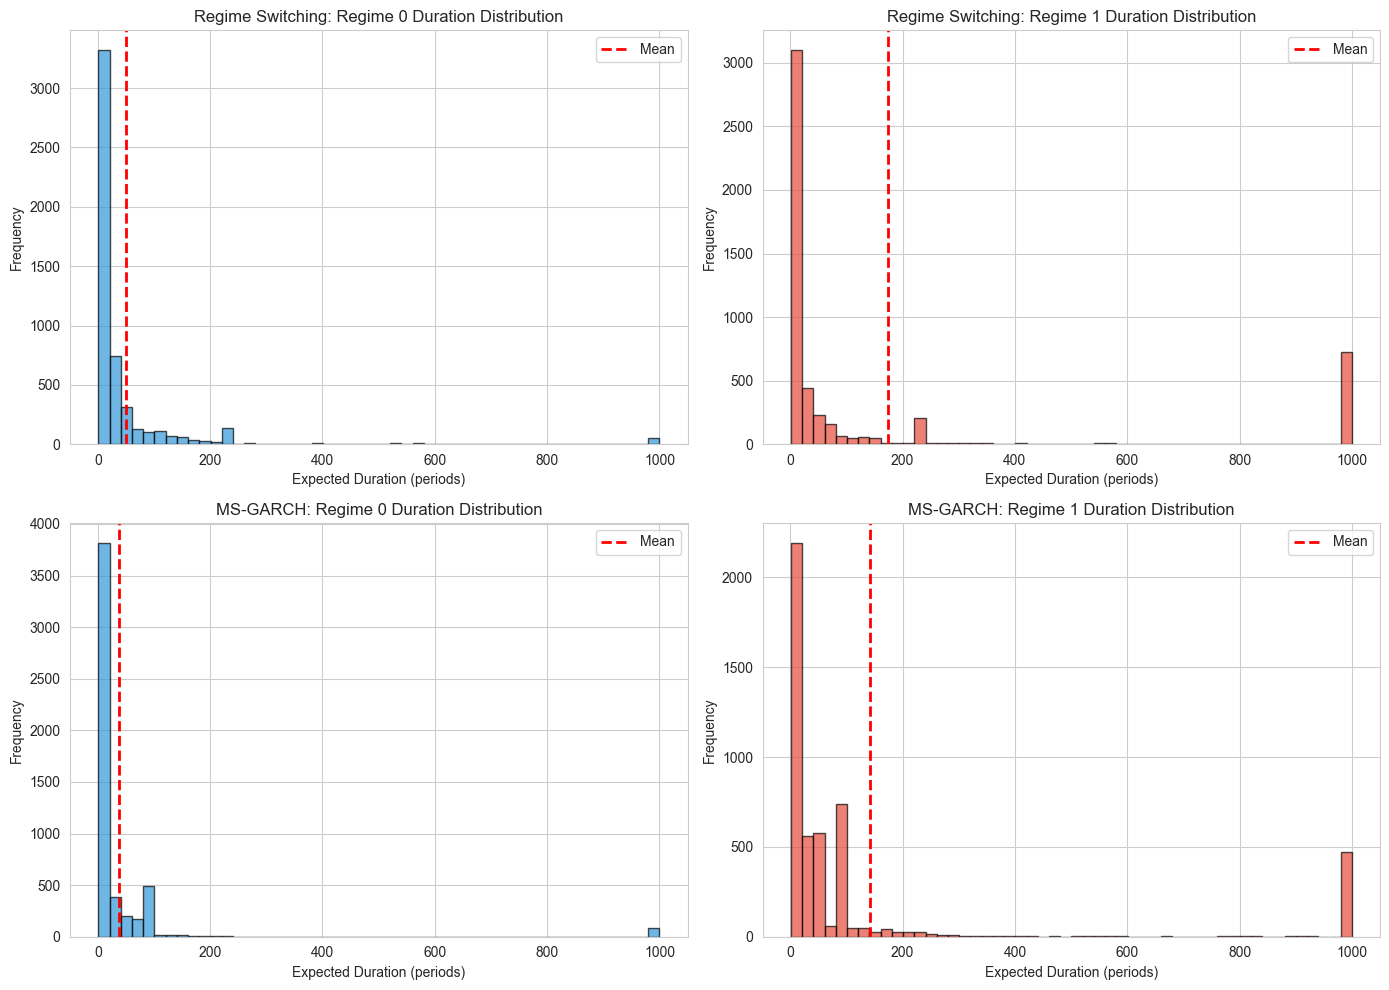


Note: Durations capped at 1000 periods for visualization
Infinite/extreme durations filtered:
  RS Regime 0: 0
  RS Regime 1: 0
  MS-GARCH Regime 0: 90
  MS-GARCH Regime 1: 754


In [33]:
# Visualize duration distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Filter out infinite values and cap durations for better visualization
def filter_duration(series, max_duration=1000):
    """Filter out infinite values and cap at max_duration for visualization"""
    return series.replace([np.inf, -np.inf], np.nan).clip(upper=max_duration)

# Regime Switching - Regime 0
rs_dur_0_filtered = filter_duration(rs_params['duration_regime_0'])
axes[0, 0].hist(rs_dur_0_filtered.dropna(), bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(rs_dur_0_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Expected Duration (periods)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Regime Switching: Regime 0 Duration Distribution')
axes[0, 0].legend()

# Regime Switching - Regime 1
rs_dur_1_filtered = filter_duration(rs_params['duration_regime_1'])
axes[0, 1].hist(rs_dur_1_filtered.dropna(), bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(rs_dur_1_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].set_xlabel('Expected Duration (periods)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Regime Switching: Regime 1 Duration Distribution')
axes[0, 1].legend()

# MS-GARCH - Regime 0
ms_dur_0_filtered = filter_duration(ms_garch['duration_regime_0'])
axes[1, 0].hist(ms_dur_0_filtered.dropna(), bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(ms_dur_0_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Expected Duration (periods)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('MS-GARCH: Regime 0 Duration Distribution')
axes[1, 0].legend()

# MS-GARCH - Regime 1
ms_dur_1_filtered = filter_duration(ms_garch['duration_regime_1'])
axes[1, 1].hist(ms_dur_1_filtered.dropna(), bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(ms_dur_1_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 1].set_xlabel('Expected Duration (periods)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('MS-GARCH: Regime 1 Duration Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print info about filtered values
print(f"\nNote: Durations capped at 1000 periods for visualization")
print(f"Infinite/extreme durations filtered:")
print(f"  RS Regime 0: {rs_params['duration_regime_0'].isna().sum() + (rs_params['duration_regime_0'] > 1000).sum()}")
print(f"  RS Regime 1: {rs_params['duration_regime_1'].isna().sum() + (rs_params['duration_regime_1'] > 1000).sum()}")
print(f"  MS-GARCH Regime 0: {ms_garch['duration_regime_0'].isna().sum() + (ms_garch['duration_regime_0'] > 1000).sum()}")
print(f"  MS-GARCH Regime 1: {ms_garch['duration_regime_1'].isna().sum() + (ms_garch['duration_regime_1'] > 1000).sum()}")

## 5. Parameter Comparison Between Regimes

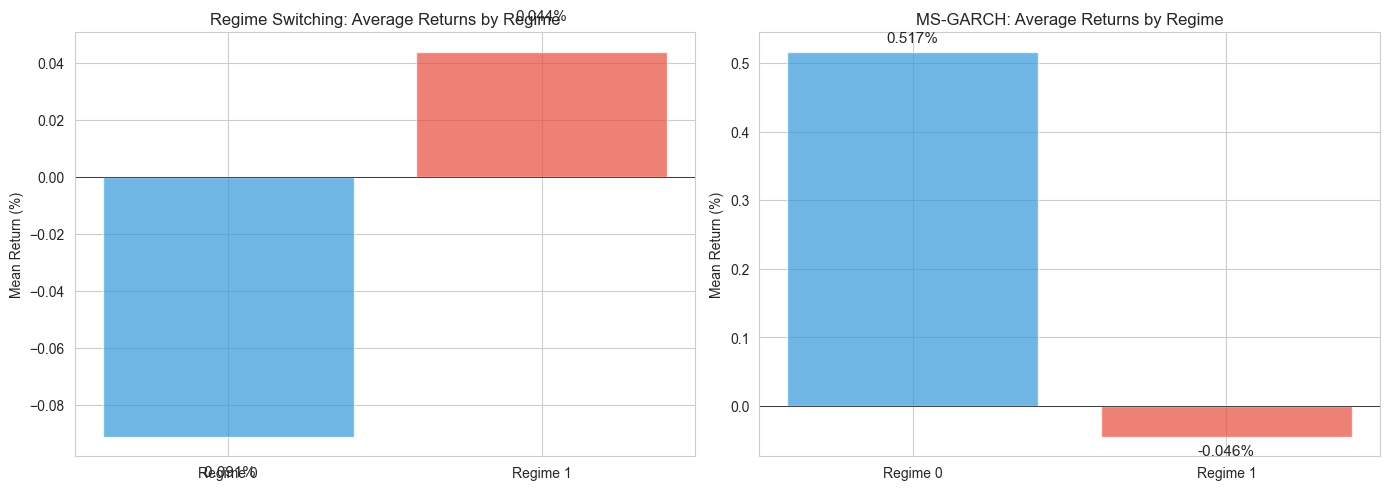

In [34]:
# Compare mean returns between regimes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime Switching
rs_means = rs_params[['regime_0_mean', 'regime_1_mean']].mean() * 100  # Convert to percentage
axes[0].bar(['Regime 0', 'Regime 1'], rs_means, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Mean Return (%)')
axes[0].set_title('Regime Switching: Average Returns by Regime')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for i, v in enumerate(rs_means):
    axes[0].text(i, v + (0.01 if v > 0 else -0.01), f'{v:.3f}%', ha='center', va='bottom' if v > 0 else 'top', fontsize=11)

# MS-GARCH
ms_means = ms_garch[['mu_0', 'mu_1']].mean() * 100
axes[1].bar(['Regime 0', 'Regime 1'], ms_means, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Mean Return (%)')
axes[1].set_title('MS-GARCH: Average Returns by Regime')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for i, v in enumerate(ms_means):
    axes[1].text(i, v + (0.01 if v > 0 else -0.01), f'{v:.3f}%', ha='center', va='bottom' if v > 0 else 'top', fontsize=11)

plt.tight_layout()
plt.show()

In [35]:
# Detailed parameter comparison table
print('='*80)
print('REGIME SWITCHING MODEL - PARAMETER COMPARISON')
print('='*80)
comparison_rs = pd.DataFrame({
    'Parameter': ['Mean Return', 'Volatility', 'Degrees of Freedom (nu)'],
    'Regime 0': [
        f"{rs_params['regime_0_mean'].mean()*100:.4f}%",
        f"{rs_params['regime_0_vol'].mean()*100:.4f}%",
        f"{rs_params['regime_0_nu'].mean():.2f}"
    ],
    'Regime 1': [
        f"{rs_params['regime_1_mean'].mean()*100:.4f}%",
        f"{rs_params['regime_1_vol'].mean()*100:.4f}%",
        f"{rs_params['regime_1_nu'].mean():.2f}"
    ],
    'Difference': [
        f"{(rs_params['regime_1_mean'].mean() - rs_params['regime_0_mean'].mean())*100:.4f}%",
        f"{(rs_params['regime_1_vol'].mean() - rs_params['regime_0_vol'].mean())*100:.4f}%",
        f"{rs_params['regime_1_nu'].mean() - rs_params['regime_0_nu'].mean():.2f}"
    ]
})
display(comparison_rs)

print('\n' + '='*80)
print('MS-GARCH MODEL - PARAMETER COMPARISON')
print('='*80)
comparison_ms = pd.DataFrame({
    'Parameter': ['Mean Return', 'Degrees of Freedom (nu)', 'Omega', 'Alpha', 'Beta'],
    'Regime 0': [
        f"{ms_garch['mu_0'].mean()*100:.4f}%",
        f"{ms_garch['nu_0'].mean():.2f}",
        f"{ms_garch['omega_0'].mean():.6f}",
        f"{ms_garch['alpha_0'].mean():.6f}",
        f"{ms_garch['beta_0'].mean():.6f}"
    ],
    'Regime 1': [
        f"{ms_garch['mu_1'].mean()*100:.4f}%",
        f"{ms_garch['nu_1'].mean():.2f}",
        f"{ms_garch['omega_1'].mean():.6f}",
        f"{ms_garch['alpha_1'].mean():.6f}",
        f"{ms_garch['beta_1'].mean():.6f}"
    ],
    'Ratio (R1/R0)': [
        f"{ms_garch['mu_1'].mean() / ms_garch['mu_0'].mean() if ms_garch['mu_0'].mean() != 0 else np.nan:.2f}",
        f"{ms_garch['nu_1'].mean() / ms_garch['nu_0'].mean():.2f}",
        f"{ms_garch['omega_1'].mean() / ms_garch['omega_0'].mean() if ms_garch['omega_0'].mean() != 0 else np.nan:.2f}",
        f"{ms_garch['alpha_1'].mean() / ms_garch['alpha_0'].mean() if ms_garch['alpha_0'].mean() != 0 else np.nan:.2f}",
        f"{ms_garch['beta_1'].mean() / ms_garch['beta_0'].mean():.2f}"
    ]
})
display(comparison_ms)

REGIME SWITCHING MODEL - PARAMETER COMPARISON


,Parameter,Regime 0,Regime 1,Difference
0,Mean Return,-0.0912%,0.0439%,0.1351%
1,Volatility,0.4692%,1.8012%,1.3320%
2,Degrees of Freedom (nu),128.07,47.62,-80.45


REGIME SWITCHING MODEL - PARAMETER COMPARISON


,Parameter,Regime 0,Regime 1,Difference
0,Mean Return,-0.0912%,0.0439%,0.1351%
1,Volatility,0.4692%,1.8012%,1.3320%
2,Degrees of Freedom (nu),128.07,47.62,-80.45



MS-GARCH MODEL - PARAMETER COMPARISON


,Parameter,Regime 0,Regime 1,Ratio (R1/R0)
0,Mean Return,0.5166%,-0.0457%,-0.09
1,Degrees of Freedom (nu),142054160.01,25.42,0.00
2,Omega,0.000007,61047.553017,9075964800.72
3,Alpha,0.079897,0.140675,1.76
4,Beta,0.419681,0.595014,1.42


## 6. Volatility Analysis by Regime

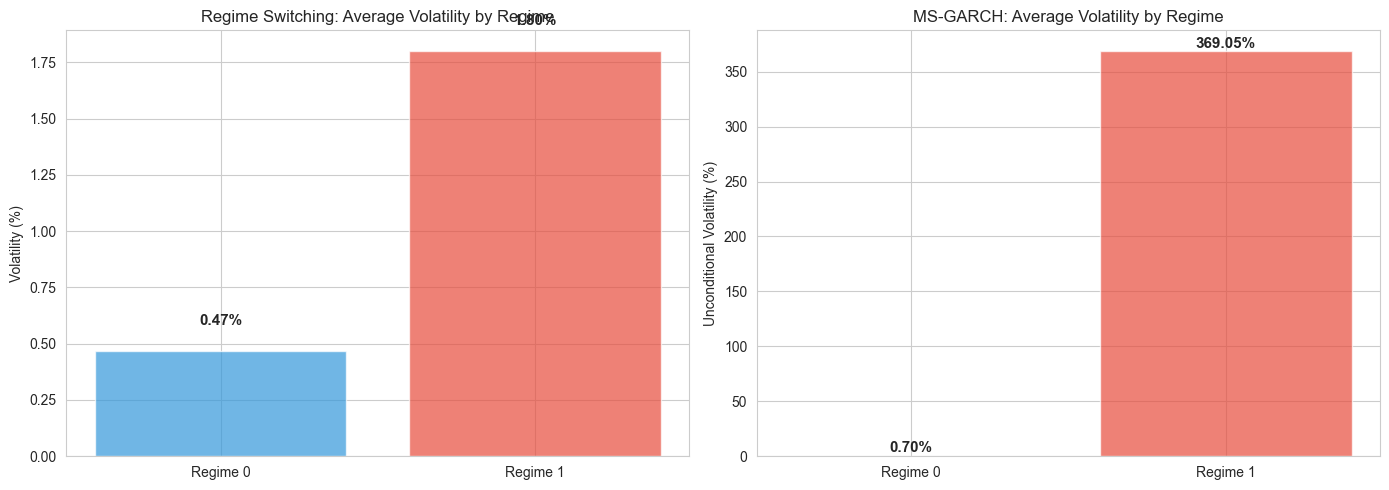

Regime Switching: Volatility Ratio (Regime 1 / Regime 0) = 3.84x
MS-GARCH: Volatility Ratio (Regime 1 / Regime 0) = 528.75x


In [36]:
# Volatility comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime Switching
rs_vols = rs_params[['regime_0_vol', 'regime_1_vol']].mean() * 100
axes[0].bar(['Regime 0', 'Regime 1'], rs_vols, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Volatility (%)')
axes[0].set_title('Regime Switching: Average Volatility by Regime')
for i, v in enumerate(rs_vols):
    axes[0].text(i, v + 0.1, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# MS-GARCH - Calculate implied volatility from GARCH parameters
# Unconditional variance = omega / (1 - alpha - beta)
ms_garch['uncond_vol_0'] = np.sqrt(ms_garch['omega_0'] / (1 - ms_garch['alpha_0'] - ms_garch['beta_0']))
ms_garch['uncond_vol_1'] = np.sqrt(ms_garch['omega_1'] / (1 - ms_garch['alpha_1'] - ms_garch['beta_1']))

ms_vols = ms_garch[['uncond_vol_0', 'uncond_vol_1']].mean() * 100
axes[1].bar(['Regime 0', 'Regime 1'], ms_vols, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Unconditional Volatility (%)')
axes[1].set_title('MS-GARCH: Average Volatility by Regime')
for i, v in enumerate(ms_vols):
    axes[1].text(i, v + 0.1, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Regime Switching: Volatility Ratio (Regime 1 / Regime 0) = {rs_vols['regime_1_vol'] / rs_vols['regime_0_vol']:.2f}x")
print(f"MS-GARCH: Volatility Ratio (Regime 1 / Regime 0) = {ms_vols['uncond_vol_1'] / ms_vols['uncond_vol_0']:.2f}x")

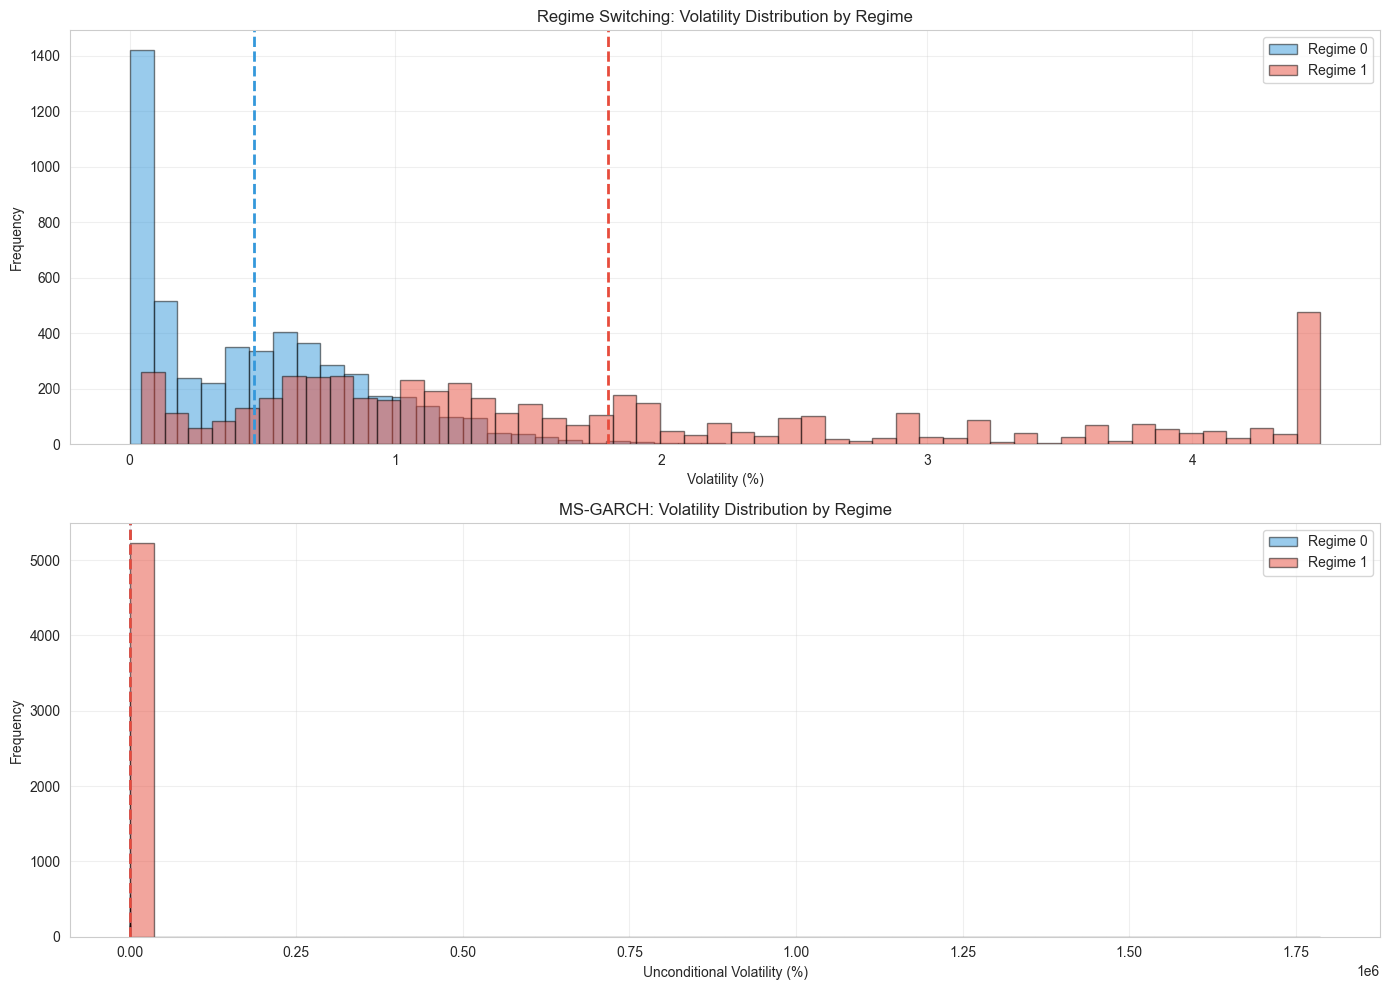

In [37]:
# Volatility distributions
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Regime Switching
axes[0].hist(rs_params['regime_0_vol']*100, bins=50, alpha=0.5, label='Regime 0', color='#3498db', edgecolor='black')
axes[0].hist(rs_params['regime_1_vol']*100, bins=50, alpha=0.5, label='Regime 1', color='#e74c3c', edgecolor='black')
axes[0].axvline(rs_params['regime_0_vol'].mean()*100, color='#3498db', linestyle='--', linewidth=2)
axes[0].axvline(rs_params['regime_1_vol'].mean()*100, color='#e74c3c', linestyle='--', linewidth=2)
axes[0].set_xlabel('Volatility (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Regime Switching: Volatility Distribution by Regime')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MS-GARCH
axes[1].hist(ms_garch['uncond_vol_0']*100, bins=50, alpha=0.5, label='Regime 0', color='#3498db', edgecolor='black')
axes[1].hist(ms_garch['uncond_vol_1']*100, bins=50, alpha=0.5, label='Regime 1', color='#e74c3c', edgecolor='black')
axes[1].axvline(ms_garch['uncond_vol_0'].mean()*100, color='#3498db', linestyle='--', linewidth=2)
axes[1].axvline(ms_garch['uncond_vol_1'].mean()*100, color='#e74c3c', linestyle='--', linewidth=2)
axes[1].set_xlabel('Unconditional Volatility (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('MS-GARCH: Volatility Distribution by Regime')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Transition Probability Analysis

In [38]:
# Analyze transition probabilities
print('='*80)
print('REGIME SWITCHING - TRANSITION PROBABILITIES')
print('='*80)
print(f"P(stay in Regime 0 | in Regime 0): {rs_params['transition_prob_00'].mean():.4f}")
print(f"P(switch to Regime 1 | in Regime 0): {rs_params['transition_prob_01'].mean():.4f}")
print(f"P(switch to Regime 0 | in Regime 1): {rs_params['transition_prob_10'].mean():.4f}")
print(f"P(stay in Regime 1 | in Regime 1): {rs_params['transition_prob_11'].mean():.4f}")

print('\n' + '='*80)
print('MS-GARCH - TRANSITION PROBABILITIES')
print('='*80)
print(f"P(stay in Regime 0 | in Regime 0): {ms_garch['p00'].mean():.4f}")
print(f"P(switch to Regime 1 | in Regime 0): {(1 - ms_garch['p00']).mean():.4f}")
print(f"P(switch to Regime 0 | in Regime 1): {(1 - ms_garch['p11']).mean():.4f}")
print(f"P(stay in Regime 1 | in Regime 1): {ms_garch['p11'].mean():.4f}")

REGIME SWITCHING - TRANSITION PROBABILITIES
P(stay in Regime 0 | in Regime 0): 0.7218
P(switch to Regime 1 | in Regime 0): 0.2782
P(switch to Regime 0 | in Regime 1): 0.2925
P(stay in Regime 1 | in Regime 1): 0.7075

MS-GARCH - TRANSITION PROBABILITIES
P(stay in Regime 0 | in Regime 0): 0.7812
P(switch to Regime 1 | in Regime 0): 0.2188
P(switch to Regime 0 | in Regime 1): 0.0997
P(stay in Regime 1 | in Regime 1): 0.9003


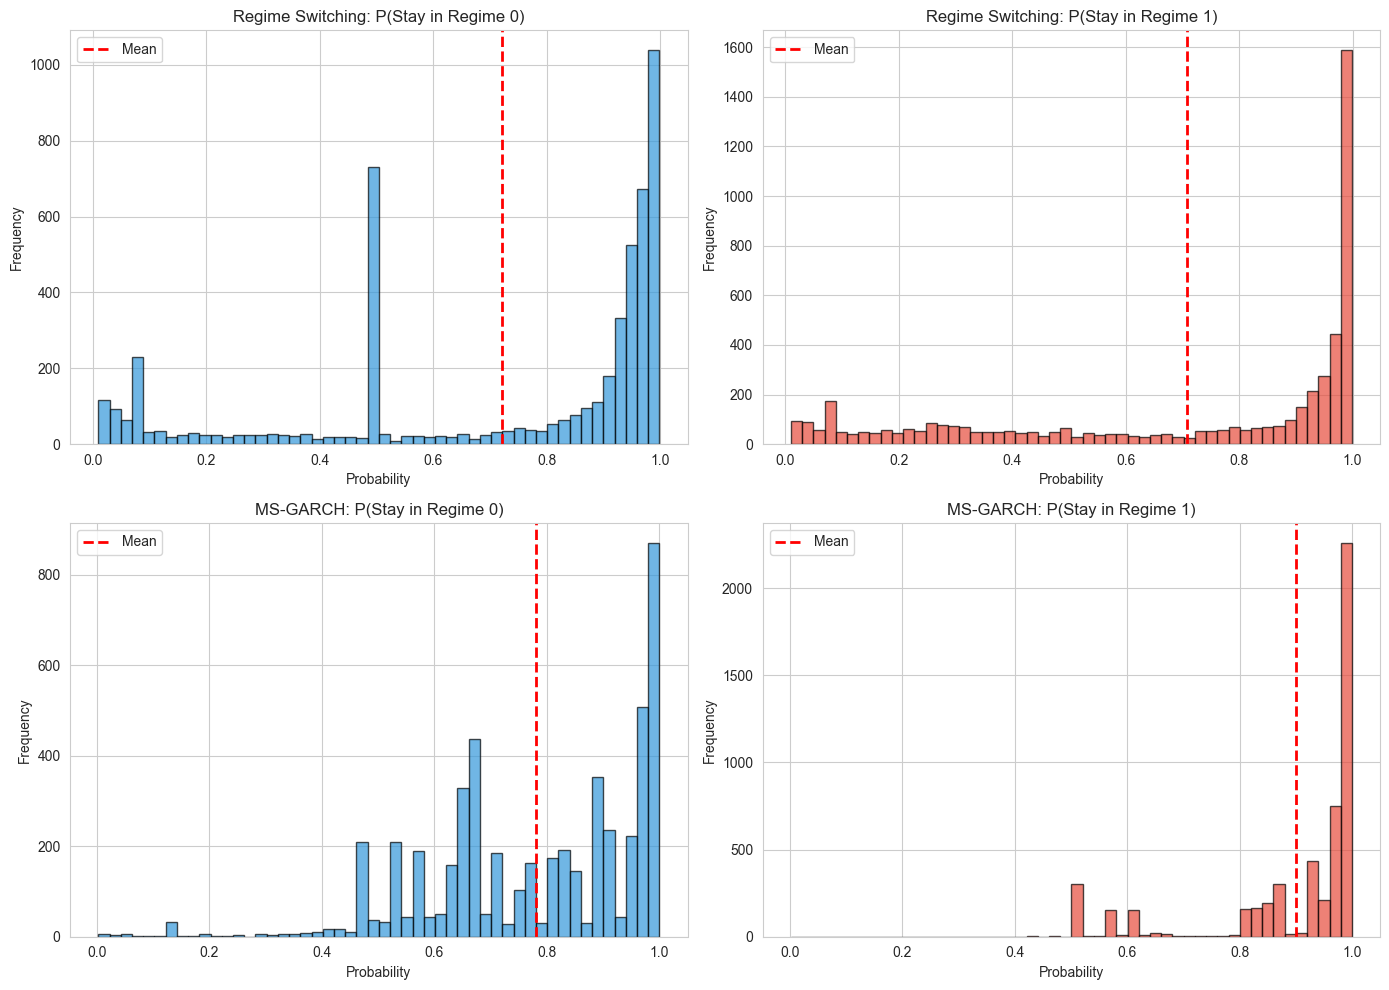

In [39]:
# Visualize transition probabilities
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Regime Switching - Persistence
axes[0, 0].hist(rs_params['transition_prob_00'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(rs_params['transition_prob_00'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Probability')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Regime Switching: P(Stay in Regime 0)')
axes[0, 0].legend()

axes[0, 1].hist(rs_params['transition_prob_11'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(rs_params['transition_prob_11'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].set_xlabel('Probability')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Regime Switching: P(Stay in Regime 1)')
axes[0, 1].legend()

# MS-GARCH - Persistence
axes[1, 0].hist(ms_garch['p00'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(ms_garch['p00'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Probability')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('MS-GARCH: P(Stay in Regime 0)')
axes[1, 0].legend()

axes[1, 1].hist(ms_garch['p11'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(ms_garch['p11'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 1].set_xlabel('Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('MS-GARCH: P(Stay in Regime 1)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

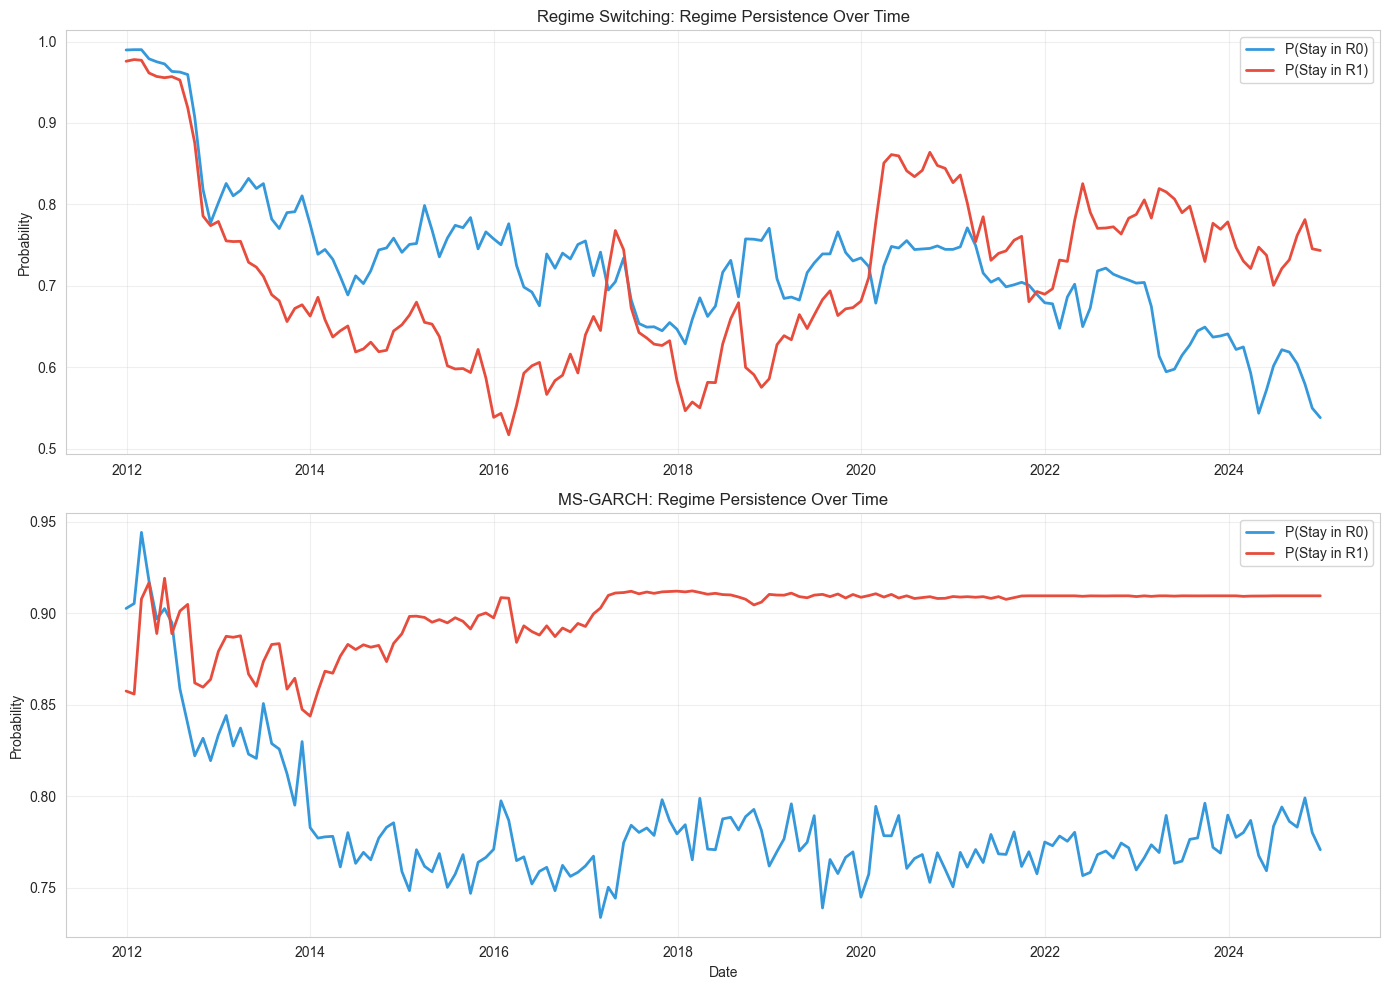

In [40]:
# Transition probabilities over time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Regime Switching
rs_trans_time = rs_params.groupby('date')[['transition_prob_00', 'transition_prob_11']].mean()
axes[0].plot(rs_trans_time.index, rs_trans_time['transition_prob_00'], label='P(Stay in R0)', color='#3498db', linewidth=2)
axes[0].plot(rs_trans_time.index, rs_trans_time['transition_prob_11'], label='P(Stay in R1)', color='#e74c3c', linewidth=2)
axes[0].set_ylabel('Probability')
axes[0].set_title('Regime Switching: Regime Persistence Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MS-GARCH
ms_trans_time = ms_garch.groupby('date')[['p00', 'p11']].mean()
axes[1].plot(ms_trans_time.index, ms_trans_time['p00'], label='P(Stay in R0)', color='#3498db', linewidth=2)
axes[1].plot(ms_trans_time.index, ms_trans_time['p11'], label='P(Stay in R1)', color='#e74c3c', linewidth=2)
axes[1].set_ylabel('Probability')
axes[1].set_xlabel('Date')
axes[1].set_title('MS-GARCH: Regime Persistence Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Time Series Visualization of Regimes

Let's look at a specific company over time.

In [41]:
# Select a company to analyze
sample_gvkey = rs_params['gvkey'].iloc[0]
print(f"Analyzing company: {sample_gvkey}")

# Filter data for this company
rs_company = rs_params[rs_params['gvkey'] == sample_gvkey].sort_values('date')
ms_company = ms_garch[ms_garch['gvkey'] == sample_gvkey].sort_values('date')

Analyzing company: 14447


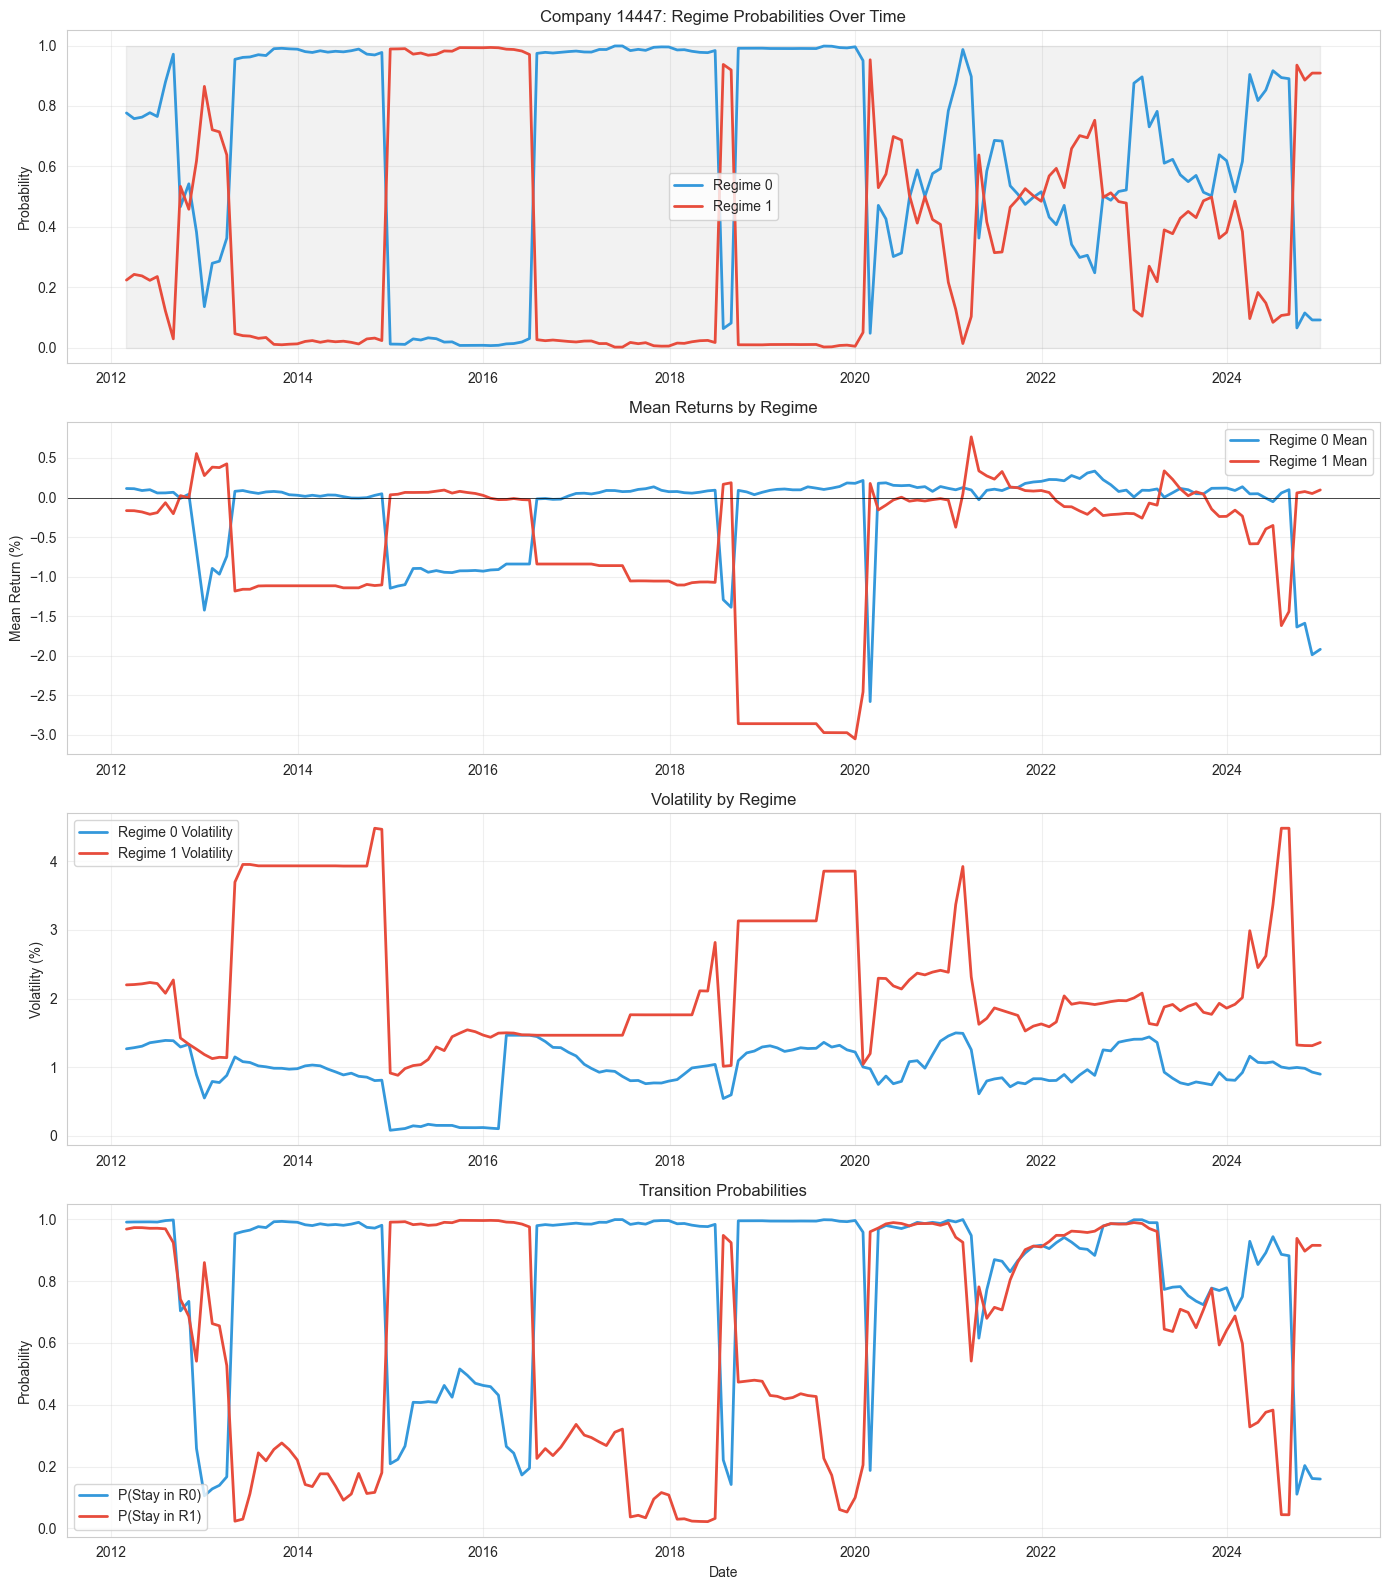

In [42]:
# Plot regime probabilities and parameters over time
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# Regime probabilities
axes[0].plot(rs_company['date'], rs_company['steady_state_regime_0'], label='Regime 0', color='#3498db', linewidth=2)
axes[0].plot(rs_company['date'], rs_company['steady_state_regime_1'], label='Regime 1', color='#e74c3c', linewidth=2)
axes[0].fill_between(rs_company['date'], 0, 1, alpha=0.1, color='gray')
axes[0].set_ylabel('Probability')
axes[0].set_title(f'Company {sample_gvkey}: Regime Probabilities Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Mean returns by regime
axes[1].plot(rs_company['date'], rs_company['regime_0_mean']*100, label='Regime 0 Mean', color='#3498db', linewidth=2)
axes[1].plot(rs_company['date'], rs_company['regime_1_mean']*100, label='Regime 1 Mean', color='#e74c3c', linewidth=2)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_ylabel('Mean Return (%)')
axes[1].set_title('Mean Returns by Regime')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Volatility by regime
axes[2].plot(rs_company['date'], rs_company['regime_0_vol']*100, label='Regime 0 Volatility', color='#3498db', linewidth=2)
axes[2].plot(rs_company['date'], rs_company['regime_1_vol']*100, label='Regime 1 Volatility', color='#e74c3c', linewidth=2)
axes[2].set_ylabel('Volatility (%)')
axes[2].set_title('Volatility by Regime')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Transition probabilities
axes[3].plot(rs_company['date'], rs_company['transition_prob_00'], label='P(Stay in R0)', color='#3498db', linewidth=2)
axes[3].plot(rs_company['date'], rs_company['transition_prob_11'], label='P(Stay in R1)', color='#e74c3c', linewidth=2)
axes[3].set_ylabel('Probability')
axes[3].set_xlabel('Date')
axes[3].set_title('Transition Probabilities')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Statistical Tests for Regime Differences

In [43]:
# Perform t-tests to check if regime parameters are significantly different
from scipy.stats import ttest_rel, ttest_ind

print('='*80)
print('REGIME SWITCHING - STATISTICAL TESTS FOR PARAMETER DIFFERENCES')
print('='*80)

# Test mean returns
t_stat, p_value = ttest_rel(rs_params['regime_0_mean'], rs_params['regime_1_mean'])
print(f"\nMean Returns:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

# Test volatility
t_stat, p_value = ttest_rel(rs_params['regime_0_vol'], rs_params['regime_1_vol'])
print(f"\nVolatility:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

# Test degrees of freedom
t_stat, p_value = ttest_rel(rs_params['regime_0_nu'], rs_params['regime_1_nu'])
print(f"\nDegrees of Freedom (nu):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

print('\n' + '='*80)
print('MS-GARCH - STATISTICAL TESTS FOR PARAMETER DIFFERENCES')
print('='*80)

# Test mean returns
t_stat, p_value = ttest_rel(ms_garch['mu_0'], ms_garch['mu_1'])
print(f"\nMean Returns:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

# Test GARCH parameters
t_stat, p_value = ttest_rel(ms_garch['alpha_0'], ms_garch['alpha_1'])
print(f"\nAlpha (ARCH effect):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

t_stat, p_value = ttest_rel(ms_garch['beta_0'], ms_garch['beta_1'])
print(f"\nBeta (GARCH effect):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

REGIME SWITCHING - STATISTICAL TESTS FOR PARAMETER DIFFERENCES

Mean Returns:
  t-statistic: -2.6181
  p-value: 8.8668e-03
  Significant at 5% level: Yes

Volatility:
  t-statistic: -76.1631
  p-value: 0.0000e+00
  Significant at 5% level: Yes

Degrees of Freedom (nu):
  t-statistic: 25.4335
  p-value: 1.2141e-134
  Significant at 5% level: Yes

MS-GARCH - STATISTICAL TESTS FOR PARAMETER DIFFERENCES

Mean Returns:
  t-statistic: 9.5046
  p-value: 2.9784e-21
  Significant at 5% level: Yes

Alpha (ARCH effect):
  t-statistic: -13.9739
  p-value: 1.3561e-43
  Significant at 5% level: Yes

Beta (GARCH effect):
  t-statistic: -26.5929
  p-value: 2.9494e-146
  Significant at 5% level: Yes


In [44]:
# Effect sizes (Cohen's d)
def cohens_d(x, y):
    """Calculate Cohen's d for effect size"""
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)

print('='*80)
print('EFFECT SIZES (Cohen\'s d)')
print('='*80)
print("\nRegime Switching:")
print(f"  Mean Returns: d = {cohens_d(rs_params['regime_0_mean'], rs_params['regime_1_mean']):.4f}")
print(f"  Volatility: d = {cohens_d(rs_params['regime_0_vol'], rs_params['regime_1_vol']):.4f}")
print(f"  Degrees of Freedom: d = {cohens_d(rs_params['regime_0_nu'], rs_params['regime_1_nu']):.4f}")

print("\nMS-GARCH:")
print(f"  Mean Returns: d = {cohens_d(ms_garch['mu_0'], ms_garch['mu_1']):.4f}")
print(f"  Alpha: d = {cohens_d(ms_garch['alpha_0'], ms_garch['alpha_1']):.4f}")
print(f"  Beta: d = {cohens_d(ms_garch['beta_0'], ms_garch['beta_1']):.4f}")

print("\nInterpretation: |d| < 0.2 = small, 0.2-0.8 = medium, > 0.8 = large effect")

EFFECT SIZES (Cohen's d)

Regime Switching:
  Mean Returns: d = -0.0512
  Volatility: d = -1.3273
  Degrees of Freedom: d = 0.5170

MS-GARCH:
  Mean Returns: d = 0.1855
  Alpha: d = -0.2913
  Beta: d = -0.4325

Interpretation: |d| < 0.2 = small, 0.2-0.8 = medium, > 0.8 = large effect


## 10. Cross-Sectional Analysis Across Companies

In [45]:
# Compare characteristics across companies
company_stats_rs = rs_params.groupby('gvkey').agg({
    'regime_0_mean': 'mean',
    'regime_1_mean': 'mean',
    'regime_0_vol': 'mean',
    'regime_1_vol': 'mean',
    'steady_state_regime_0': 'mean',
    'steady_state_regime_1': 'mean',
    'duration_regime_0': 'mean',
    'duration_regime_1': 'mean'
}).reset_index()

# Add volatility ratio
company_stats_rs['vol_ratio'] = company_stats_rs['regime_1_vol'] / company_stats_rs['regime_0_vol']

print('Company-Level Statistics (Regime Switching):')
display(company_stats_rs.head(10))

Company-Level Statistics (Regime Switching):


,gvkey,regime_0_mean,regime_1_mean,regime_0_vol,regime_1_vol,steady_state_regime_0,steady_state_regime_1,duration_regime_0,duration_regime_1,vol_ratio
0,14447,-0.001510,-6.303236e-03,0.009559,0.022558,0.651902,0.348098,92.464469,29.328765,2.359815
1,15532,0.021647,-2.407414e-04,0.000214,0.010844,0.264331,0.735669,24.491475,513.862976,50.754402
2,15549,-0.063280,1.945265e-05,0.000097,0.009906,0.122035,0.877965,5.024565,787.467041,102.173102
3,15617,-0.108540,-1.871507e-02,0.000201,0.014824,0.301147,0.698853,53.517457,637.743794,73.774136
4,15677,-0.006583,8.433615e-03,0.001224,0.014396,0.678521,0.321479,160.503699,82.257860,11.764844
5,15724,0.000131,-4.372602e-05,0.000987,0.025929,0.667300,0.332700,52.758639,22.124874,26.282893
6,16348,0.058373,2.540074e-02,0.000802,0.014137,0.638081,0.361919,203.742915,247.013903,17.637983
7,17436,0.000396,1.500621e-04,0.007778,0.021091,0.694683,0.305317,45.626883,9.779514,2.711478
8,17452,0.000693,5.144435e-04,0.006136,0.013855,0.574047,0.425953,34.743698,11.077949,2.257969
9,19349,0.000164,6.205174e-07,0.007603,0.017696,0.805469,0.194531,54.450888,14.263613,2.327385


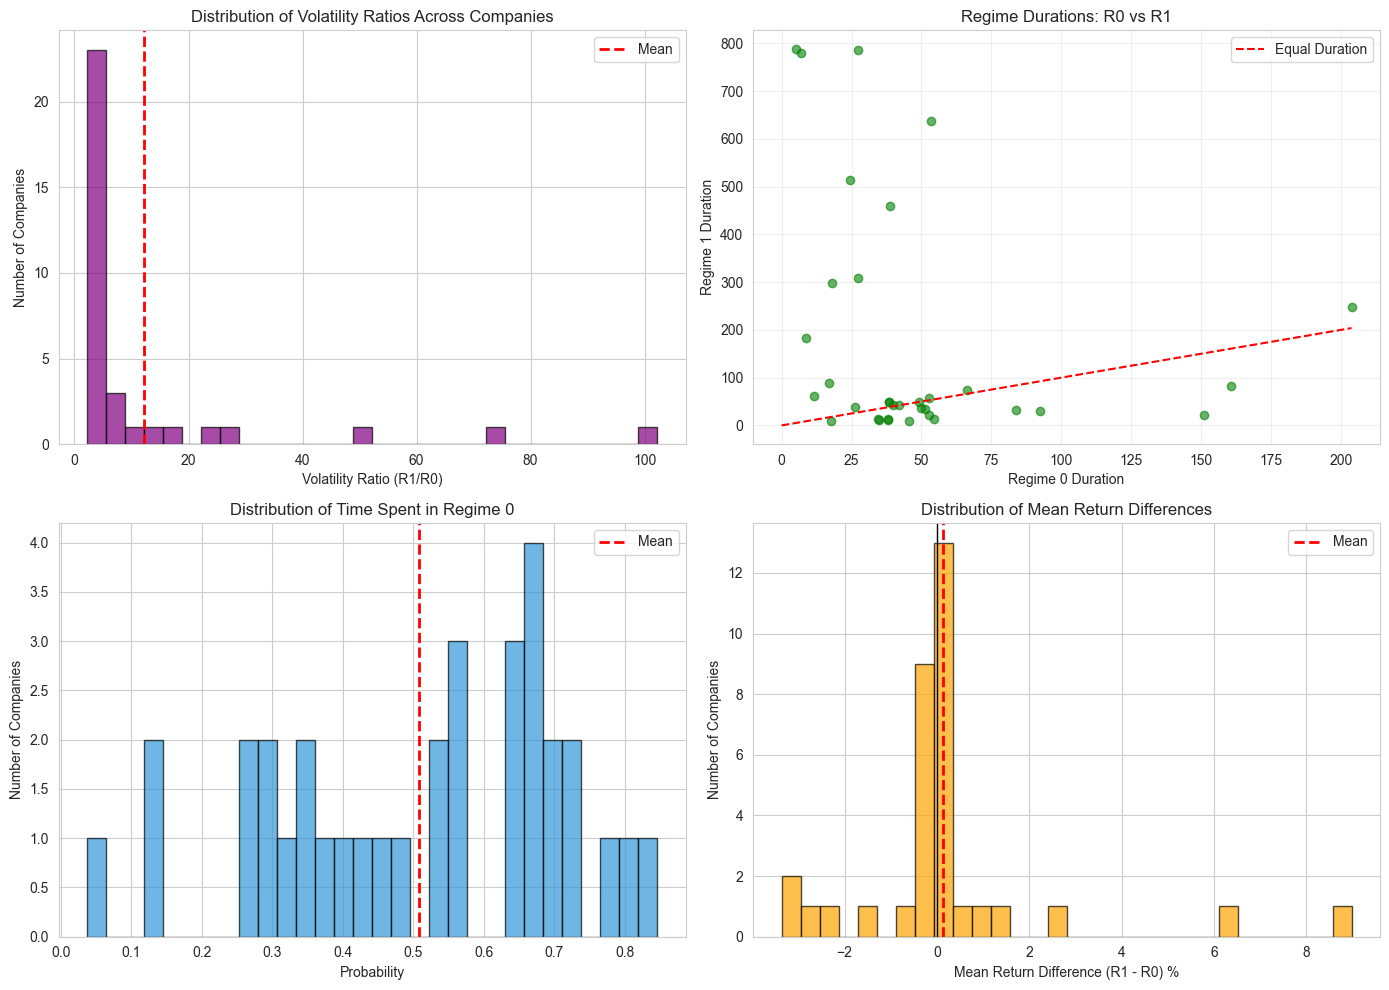

In [46]:
# Visualize company-level differences
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Volatility ratio across companies
axes[0, 0].hist(company_stats_rs['vol_ratio'], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(company_stats_rs['vol_ratio'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Volatility Ratio (R1/R0)')
axes[0, 0].set_ylabel('Number of Companies')
axes[0, 0].set_title('Distribution of Volatility Ratios Across Companies')
axes[0, 0].legend()

# Duration comparison
axes[0, 1].scatter(company_stats_rs['duration_regime_0'], company_stats_rs['duration_regime_1'], alpha=0.6, color='green')
axes[0, 1].plot([0, company_stats_rs['duration_regime_0'].max()], [0, company_stats_rs['duration_regime_0'].max()], 'r--', label='Equal Duration')
axes[0, 1].set_xlabel('Regime 0 Duration')
axes[0, 1].set_ylabel('Regime 1 Duration')
axes[0, 1].set_title('Regime Durations: R0 vs R1')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Regime frequency
axes[1, 0].hist(company_stats_rs['steady_state_regime_0'], bins=30, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(company_stats_rs['steady_state_regime_0'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Probability')
axes[1, 0].set_ylabel('Number of Companies')
axes[1, 0].set_title('Distribution of Time Spent in Regime 0')
axes[1, 0].legend()

# Mean return difference
company_stats_rs['mean_diff'] = company_stats_rs['regime_1_mean'] - company_stats_rs['regime_0_mean']
axes[1, 1].hist(company_stats_rs['mean_diff']*100, bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(company_stats_rs['mean_diff'].mean()*100, color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xlabel('Mean Return Difference (R1 - R0) %')
axes[1, 1].set_ylabel('Number of Companies')
axes[1, 1].set_title('Distribution of Mean Return Differences')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [47]:
# Summary of key findings
print('='*80)
print('KEY FINDINGS SUMMARY')
print('='*80)

print('\n1. REGIME FREQUENCY:')
print(f"   - Average time in Regime 0 (RS): {rs_params['steady_state_regime_0'].mean():.2%}")
print(f"   - Average time in Regime 1 (RS): {rs_params['steady_state_regime_1'].mean():.2%}")
print(f"   - Average time in Regime 0 (MS-GARCH): {ms_garch['steady_state_regime_0'].mean():.2%}")
print(f"   - Average time in Regime 1 (MS-GARCH): {ms_garch['steady_state_regime_1'].mean():.2%}")

print('\n2. REGIME PERSISTENCE:')
print(f"   - Regime 0 expected duration (RS): {rs_params['duration_regime_0'].mean():.2f} periods")
print(f"   - Regime 1 expected duration (RS): {rs_params['duration_regime_1'].mean():.2f} periods")
print(f"   - Regime 0 expected duration (MS-GARCH): {ms_garch['duration_regime_0'].mean():.2f} periods")
print(f"   - Regime 1 expected duration (MS-GARCH): {ms_garch['duration_regime_1'].mean():.2f} periods")

print('\n3. PARAMETER DIFFERENCES:')
print(f"   - Mean return difference (RS): {(rs_params['regime_1_mean'].mean() - rs_params['regime_0_mean'].mean())*100:.4f}%")
print(f"   - Volatility ratio (RS): {(rs_params['regime_1_vol'].mean() / rs_params['regime_0_vol'].mean()):.2f}x")
print(f"   - Mean return difference (MS-GARCH): {(ms_garch['mu_1'].mean() - ms_garch['mu_0'].mean())*100:.4f}%")

print('\n4. CROSS-SECTIONAL VARIATION:')
print(f"   - Volatility ratio std dev: {company_stats_rs['vol_ratio'].std():.2f}")
print(f"   - Companies with higher vol in R1: {(company_stats_rs['vol_ratio'] > 1).sum()} / {len(company_stats_rs)}")
print(f"   - Companies with positive mean diff: {(company_stats_rs['mean_diff'] > 0).sum()} / {len(company_stats_rs)}")

print('\n' + '='*80)

KEY FINDINGS SUMMARY

1. REGIME FREQUENCY:
   - Average time in Regime 0 (RS): 50.87%
   - Average time in Regime 1 (RS): 49.13%
   - Average time in Regime 0 (MS-GARCH): 34.78%
   - Average time in Regime 1 (MS-GARCH): 65.22%

2. REGIME PERSISTENCE:
   - Regime 0 expected duration (RS): 49.96 periods
   - Regime 1 expected duration (RS): 173.44 periods
   - Regime 0 expected duration (MS-GARCH): inf periods
   - Regime 1 expected duration (MS-GARCH): inf periods

3. PARAMETER DIFFERENCES:
   - Mean return difference (RS): 0.1351%
   - Volatility ratio (RS): 3.84x
   - Mean return difference (MS-GARCH): -0.5622%

4. CROSS-SECTIONAL VARIATION:
   - Volatility ratio std dev: 21.84
   - Companies with higher vol in R1: 34 / 34
   - Companies with positive mean diff: 10 / 34

